# 05 - YOLOX inference demo (MyYoloX)

Este notebook sigue el estilo de los notebooks de exploracion del proyecto, pero orientado a una prueba completa de inferencia con YOLOX: carga DICOM, preprocesado y deteccion de bounding boxes.

Requisito: ejecutar el kernel en el entorno del contenedor donde MyYoloX este instalado (`pip install -e /workspace/MyYoloX`).

In [1]:
import sys
import random
from pathlib import Path

import pydicom
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / "utils").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from utils.utils import find_dicom_images
from utils.yolox_interface import YOLOXNotebookInterface

from image.apply_windowing import apply_windowing
from image.calculate_windowing import (
                                get_dicom_voi_lut_params, 
                                normalize_photometric,
                                )

In [2]:
# Rutas dentro del contenedor.
# Datasets locales montados en /workspace/Data  (host: ~/Escritorio/Datasets)
DEFAULT_DATASET_DIR = Path('/workspace/Data/INbreast/AllDICOMs/')
# DEFAULT_DATASET_DIR = Path('/workspace/Data/Mammo-MX/B1')

YOLOX_ROOT = project_root / 'MyYoloX'
EXP_FILE   = YOLOX_ROOT / 'exps/default/yolox_nano.py'
CKPT_FILE  = YOLOX_ROOT / 'archive/yolox_nano_416_roi_torch.pth'

DEVICE = 'gpu'   # cambia a 'cpu' si no tienes CUDA disponible
TSIZE  = 416
CONF   = 0.25
NMS    = 0.45

print('project_root:', project_root)
print('dataset exists:', DEFAULT_DATASET_DIR.exists(), DEFAULT_DATASET_DIR)
print('exp exists:    ', EXP_FILE.exists(),   EXP_FILE)
print('ckpt exists:   ', CKPT_FILE.exists(),  CKPT_FILE)

project_root: /workspace
dataset exists: True /workspace/Data/INbreast/AllDICOMs
exp exists:     True /workspace/MyYoloX/exps/default/yolox_nano.py
ckpt exists:    True /workspace/MyYoloX/archive/yolox_nano_416_roi_torch.pth


In [3]:
dicom_paths = find_dicom_images(DEFAULT_DATASET_DIR, include_extensionless=True)
print(f'Total DICOM encontrados: {len(dicom_paths)}')

if not dicom_paths:
    raise RuntimeError('No se encontraron DICOMs. Revisa DEFAULT_DATASET_DIR.')

idx = random.randint(0, len(dicom_paths) - 1)
image_path = dicom_paths[idx]
print('Indice:', idx)
print('Imagen seleccionada:', image_path)

Total DICOM encontrados: 410
Indice: 401
Imagen seleccionada: /workspace/Data/INbreast/AllDICOMs/53582764_465aa5ec1b59efc6_MG_R_ML_ANON.dcm


In [4]:
metadata = pydicom.dcmread(image_path)
original_image = metadata.pixel_array
original_image, _ = normalize_photometric(original_image, metadata)

try:
    voilut = get_dicom_voi_lut_params(metadata)
    print(voilut)
    windowed_image = apply_windowing(
        original_image,
        window_width=voilut['window_width'],
        window_center=voilut['window_center'],
        voi_func=voilut['voi_lut_function'],
        y_min=float(original_image.min()),
        y_max=float(original_image.max()),
        backend='np_v2',
    )
except Exception:
    # Fallback: si no hay VOI LUT usable, usamos la imagen normalizada
    windowed_image = original_image

{'window_center': 1523, 'window_width': 634, 'rescale_intercept': 0.0, 'rescale_slope': 1.0, 'voi_lut_function': 'LINEAR'}


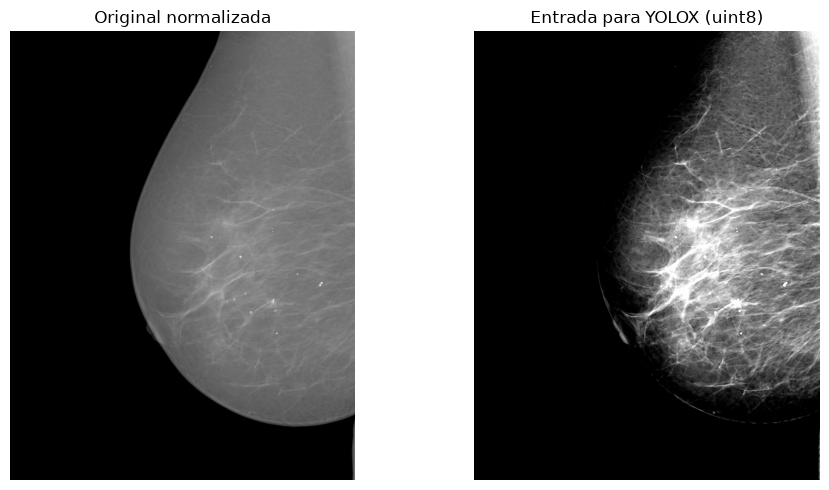

In [5]:
# Convertimos a uint8 para YOLOX
arr = windowed_image.astype('float32')
arr_min, arr_max = float(arr.min()), float(arr.max())
if arr_max > arr_min:
    arr = (arr - arr_min) / (arr_max - arr_min)
image_uint8 = (arr * 255.0).clip(0, 255).astype('uint8')

# YOLOXNotebookInterface acepta grayscale o RGB/BGR
image_for_yolo = image_uint8

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Original normalizada')
axes[0].axis('off')

axes[1].imshow(image_uint8, cmap='gray')
axes[1].set_title('Entrada para YOLOX (uint8)')
axes[1].axis('off')

plt.tight_layout()

## YOLO 

In [6]:
predictor = YOLOXNotebookInterface(
    exp_file=str(EXP_FILE),
    ckpt_path=str(CKPT_FILE),
    device=DEVICE,
    conf=CONF,
    nms=NMS,
    tsize=TSIZE,
    fp16=False,
    yolox_root=str(YOLOX_ROOT),
)
print('Predictor inicializado correctamente')

Predictor inicializado correctamente


In [7]:
detections = predictor.predict(image_for_yolo, input_format='BGR')
print(f'Detecciones: {len(detections)}')

for i, det in enumerate(detections[:10]):
    print(f"[{i}] bbox={det['bbox_xyxy']} score={det['score']:.4f} class={det['class_name']}")

Detecciones: 1
[0] bbox=[905.673095703125, 256.8985595703125, 2547.63427734375, 2916.71533203125] score=0.9849 class=person


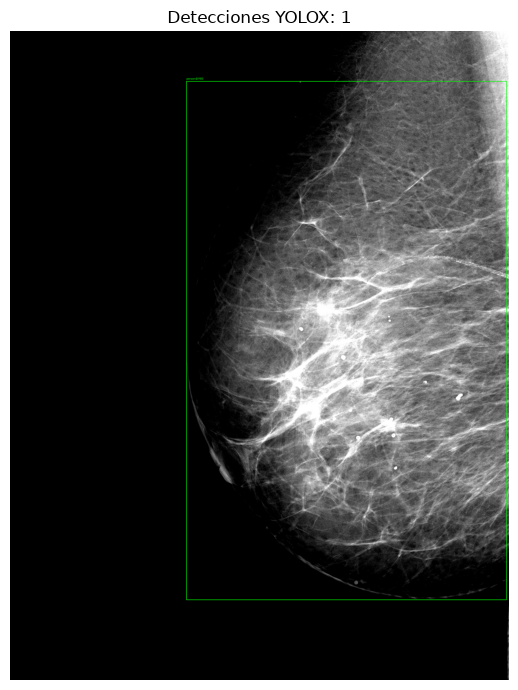

In [8]:
detections, vis_rgb = predictor.predict_with_image(image_for_yolo, input_format='BGR')

plt.figure(figsize=(7, 7))
plt.imshow(vis_rgb)
plt.title(f'Detecciones YOLOX: {len(detections)}')
plt.axis('off')
plt.tight_layout()

## Segmentacion MAseg (musculo pectoral)

Esta seccion reutiliza la misma imagen preprocesada para ejecutar segmentacion MAseg.
La salida esperada es una mascara con clases:
- 0: fondo
- 1: mama
- 2: musculo pectoral

In [9]:
from common_tasks.wrappers.segmentation import MAsegPectoralSegmentationInterface

MASEG_WEIGHTS = project_root / 'common_tasks/segmentation/BreastSegmentationUnet/maseg/weights/segmentation_weights.ckpt'
MASEG_ROOT = project_root / 'common_tasks/segmentation/BreastSegmentationUnet/maseg'

print('maseg root exists:', MASEG_ROOT.exists(), MASEG_ROOT)
print('maseg weights exists:', MASEG_WEIGHTS.exists(), MASEG_WEIGHTS)

maseg = MAsegPectoralSegmentationInterface(
    weights_path=str(MASEG_WEIGHTS),
    maseg_root=str(MASEG_ROOT),
)
print('MAseg inicializado correctamente')

maseg root exists: True /workspace/common_tasks/segmentation/BreastSegmentationUnet/maseg
maseg weights exists: True /workspace/common_tasks/segmentation/BreastSegmentationUnet/maseg/weights/segmentation_weights.ckpt


/opt/venv/lib/python3.12/site-packages/pytorch_lightning/utilities/migration/migration.py:208: You have multiple `ModelCheckpoint` callback states in this checkpoint, but we found state keys that would end up colliding with each other after an upgrade, which means we can't differentiate which of your checkpoint callbacks needs which states. At least one of your `ModelCheckpoint` callbacks will not be able to reload the state.
Lightning automatically upgraded your loaded checkpoint from v1.3.3 to v2.6.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../common_tasks/segmentation/BreastSegmentationUnet/maseg/weights/segmentation_weights.ckpt`


MAseg inicializado correctamente


In [10]:
segmentation_mask = maseg.segment(image_for_yolo, fill_holes_in_breast=True)
pectoral_mask = maseg.pectoral_mask(segmentation_mask)
stats = maseg.summary(segmentation_mask)

print('Resumen de pixeles por clase:')
print(stats)

breast_overlay, pectoral_overlay = maseg.overlay(image_for_yolo, segmentation_mask, alpha=0.35)

/workspace/common_tasks/segmentation/BreastSegmentationUnet/maseg/run_model.py:96: UserWarning: Input image is an numpy array with unknown pixel spacing. If pixel spacing is not 0.4 mm, performance can be lower
  warnings.warn(f"Input image is an numpy array with unknown pixel spacing. "


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.30 GiB. GPU 0 has a total capacity of 7.66 GiB of which 154.12 MiB is free. Including non-PyTorch memory, this process has 7.29 GiB memory in use. Of the allocated memory 7.09 GiB is allocated by PyTorch, and 34.98 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(image_for_yolo, cmap='gray')
axes[0].set_title('Entrada')
axes[0].axis('off')

axes[1].imshow(segmentation_mask, cmap='viridis')
axes[1].set_title('MAseg: 0 fondo, 1 mama, 2 pectoral')
axes[1].axis('off')

axes[2].imshow(pectoral_overlay)
axes[2].set_title('Overlay musculo pectoral')
axes[2].axis('off')

plt.tight_layout()

## Prueba opcional via APIs (Docker Compose)

Si ejecutas `docker compose up -d`, puedes testear inferencia remota desde el notebook.

Importante segun donde corre el kernel:
- Kernel en contenedor preprocessing-notebook: usar http://yolox-api:8001/infer y http://maseg-api:8002/infer.
- Kernel local (host): usar http://localhost:8001/infer y http://localhost:8002/infer.

Las siguientes celdas autodetectan esto y permiten override con variables de entorno:
- YOLOX_API_URL
- MASEG_API_URL

In [9]:
import io
import os
from pathlib import Path

import numpy as np
import requests
from PIL import Image


def _normalize_infer_url(raw_url: str) -> str:
    url = raw_url.strip().rstrip('/')
    if url.endswith('/infer'):
        return url
    if url.endswith('/health'):
        return url[:-len('/health')] + '/infer'
    return url + '/infer'


def _infer_to_health_url(infer_url: str) -> str:
    return infer_url[:-len('/infer')] + '/health'


def _dedupe_keep_order(items):
    seen = set()
    result = []
    for item in items:
        if item not in seen:
            seen.add(item)
            result.append(item)
    return result


def _resolve_api_url(service_name: str, port: int) -> tuple[str | None, str | None, list[str], list[str]]:
    env_key = f"{service_name.upper()}_API_URL"
    env_value = os.getenv(env_key, '').strip()

    candidates = []
    if env_value:
        candidates.append(_normalize_infer_url(env_value))

    in_docker_local = Path('/.dockerenv').exists()
    if in_docker_local:
        candidates.extend(
            [
                f"http://{service_name.lower()}-api:{port}/infer",
                f"http://localhost:{port}/infer",
                f"http://127.0.0.1:{port}/infer",
            ]
        )
    else:
        candidates.extend(
            [
                f"http://localhost:{port}/infer",
                f"http://127.0.0.1:{port}/infer",
                f"http://{service_name.lower()}-api:{port}/infer",
            ]
        )

    candidates = _dedupe_keep_order(candidates)

    errors = []
    for infer_url in candidates:
        health_url = _infer_to_health_url(infer_url)
        try:
            resp = requests.get(health_url, timeout=2)
            if resp.ok:
                return infer_url, health_url, candidates, errors
            errors.append(f"{health_url} -> HTTP {resp.status_code}")
        except requests.RequestException as exc:
            errors.append(f"{health_url} -> {exc}")

    return None, None, candidates, errors


def _encode_png_bytes(image: np.ndarray) -> bytes:
    arr = np.asarray(image)
    if arr.ndim == 3 and arr.shape[2] == 1:
        arr = arr[..., 0]
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    if arr.ndim == 2:
        pil_img = Image.fromarray(arr, mode='L')
    elif arr.ndim == 3 and arr.shape[2] == 3:
        pil_img = Image.fromarray(arr, mode='RGB')
    else:
        raise ValueError('image_for_yolo debe ser 2D o RGB (H,W,3)')

    buf = io.BytesIO()
    pil_img.save(buf, format='PNG')
    return buf.getvalue()


in_docker = Path('/.dockerenv').exists()

YOLOX_API_URL, yolox_health_url, yolox_candidates, YOLOX_API_ERRORS = _resolve_api_url('yolox', 8001)
MASEG_API_URL, maseg_health_url, maseg_candidates, MASEG_API_ERRORS = _resolve_api_url('maseg', 8002)

if 'image_for_yolo' not in globals():
    # Fallback para probar conectividad API sin ejecutar todas las celdas previas.
    image_for_yolo = np.zeros((416, 416), dtype=np.uint8)

payload = _encode_png_bytes(image_for_yolo)

print('Kernel en docker:', in_docker)
print('YOLOX_API_URL:', YOLOX_API_URL)
print('YOLOX health:', yolox_health_url)
print('YOLOX candidates:', yolox_candidates)
if YOLOX_API_URL is None:
    print('YOLOX no disponible. Ultimos errores:')
    for err in YOLOX_API_ERRORS[-3:]:
        print('  -', err)

print('MASEG_API_URL:', MASEG_API_URL)
print('MASEG health:', maseg_health_url)
print('MASEG candidates:', maseg_candidates)
if MASEG_API_URL is None:
    print('MASEG no disponible. Ultimos errores:')
    for err in MASEG_API_ERRORS[-3:]:
        print('  -', err)

Kernel en docker: False
YOLOX_API_URL: http://localhost:8001/infer
YOLOX health: http://localhost:8001/health
YOLOX candidates: ['http://localhost:8001/infer', 'http://127.0.0.1:8001/infer', 'http://yolox-api:8001/infer']
MASEG_API_URL: http://localhost:8002/infer
MASEG health: http://localhost:8002/health
MASEG candidates: ['http://localhost:8002/infer', 'http://127.0.0.1:8002/infer', 'http://maseg-api:8002/infer']


In [10]:
# Diagnostico rapido de conectividad API antes de inferencia
import socket
from urllib.parse import urlparse


def _tcp_reachable(host: str, port: int, timeout: float = 1.5) -> tuple[bool, str]:
    try:
        with socket.create_connection((host, port), timeout=timeout):
            return True, 'ok'
    except Exception as exc:
        return False, str(exc)


def _api_diagnostic(infer_url: str, name: str) -> None:
    parsed = urlparse(infer_url)
    host = parsed.hostname or ''
    port = parsed.port or (443 if parsed.scheme == 'https' else 80)
    health_url = infer_url[:-len('/infer')] + '/health' if infer_url.endswith('/infer') else infer_url.rstrip('/') + '/health'

    print(f'[{name}] infer_url: {infer_url}')
    print(f'[{name}] host/port: {host}:{port}')

    dns_ok = True
    try:
        resolved_ip = socket.gethostbyname(host)
        print(f'[{name}] DNS: {host} -> {resolved_ip}')
    except Exception as exc:
        dns_ok = False
        print(f'[{name}] DNS ERROR: {exc}')

    tcp_ok, tcp_msg = _tcp_reachable(host, port)
    print(f'[{name}] TCP {host}:{port}: {"OK" if tcp_ok else "ERROR"} ({tcp_msg})')

    try:
        resp = requests.get(health_url, timeout=3)
        print(f'[{name}] HEALTH {health_url}: HTTP {resp.status_code} -> {resp.text[:200]}')
    except requests.RequestException as exc:
        print(f'[{name}] HEALTH ERROR: {exc}')

    if not dns_ok and host.endswith('-api'):
        print(f'[{name}] Sugerencia: el host {host} normalmente solo resuelve dentro de la red Docker Compose.')
        print(f'[{name}] Si el kernel es local, usa localhost o 127.0.0.1.')


print('--- Diagnostico APIs ---')
print('Kernel en docker:', in_docker)
_api_diagnostic(YOLOX_API_URL, 'YOLOX')
print()
_api_diagnostic(MASEG_API_URL, 'MASEG')

--- Diagnostico APIs ---
Kernel en docker: False
[YOLOX] infer_url: http://localhost:8001/infer
[YOLOX] host/port: localhost:8001
[YOLOX] DNS: localhost -> 127.0.0.1
[YOLOX] TCP localhost:8001: OK (ok)
[YOLOX] HEALTH http://localhost:8001/health: HTTP 200 -> {"status":"ok","service":"yolox"}

[MASEG] infer_url: http://localhost:8002/infer
[MASEG] host/port: localhost:8002
[MASEG] DNS: localhost -> 127.0.0.1
[MASEG] TCP localhost:8002: OK (ok)
[MASEG] HEALTH http://localhost:8002/health: HTTP 200 -> {"status":"ok","service":"maseg"}


In [11]:
# YOLOX API
if YOLOX_API_URL is None:
    print('YOLOX no disponible. Revisa la celda anterior de resolucion de endpoints.')
else:
    try:
        resp_yolo = requests.post(
            YOLOX_API_URL,
            files={'file': ('image.png', payload, 'image/png')},
            data={'input_format': 'BGR'},
            timeout=60,
        )
    except requests.RequestException as exc:
        print('YOLOX connection error:', exc)
    else:
        print('YOLOX status:', resp_yolo.status_code)
        if resp_yolo.ok:
            yolo_json = resp_yolo.json()
            print('YOLOX detecciones:', yolo_json.get('num_detections'))
            print('Primera deteccion:', (yolo_json.get('detections') or [None])[0])
        else:
            print(resp_yolo.text)

YOLOX status: 200
YOLOX detecciones: 0
Primera deteccion: None


In [12]:
# MAseg API
if MASEG_API_URL is None:
    print('MASEG no disponible. Revisa la celda anterior de resolucion de endpoints.')
else:
    try:
        resp_maseg = requests.post(
            MASEG_API_URL,
            files={'file': ('image.png', payload, 'image/png')},
            data={'include_pectoral_mask': False, 'fill_holes_in_breast': True},
            timeout=60,
        )
    except requests.RequestException as exc:
        print('MAseg connection error:', exc)
    else:
        print('MAseg status:', resp_maseg.status_code)
        if resp_maseg.ok:
            maseg_json = resp_maseg.json()
            print('MAseg summary:', maseg_json.get('summary'))
        else:
            print(resp_maseg.text)

MAseg status: 200
MAseg summary: {'background_pixels': 173056, 'breast_pixels': 0, 'pectoral_pixels': 0}
